In [1]:
import os
import zipfile
import cv2
import numpy as np


In [2]:
pip install --upgrade torch==2.2.0 torchvision==0.17.0 scikit-learn matplotlib seaborn numpy==1.26.4 pillow tqdm --extra-index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121


In [3]:
import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ECG images often grayscale
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [6]:
import os
import shutil
import random

# ================= CONFIG =================
SOURCE_DIR = "/content/drive/MyDrive/ECGG"     # your original dataset
DEST_DIR = "dataset2"          # new dataset directory

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

# =========================================

classes = os.listdir(SOURCE_DIR)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "test", cls, img)
        )

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [7]:
train_dir = "/content/dataset2/train"
val_dir = "/content/dataset2/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from collections import Counter

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        counts[cls] = len(os.listdir(os.path.join(path, cls)))
    return counts

print("Train:", count_images("/content/dataset2/train"))
print("Val:", count_images("/content/dataset2/val"))
print("Test:", count_images("/content/dataset2/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


handling class imbalance


In [10]:
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = class_weights[train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
import os

def count_images_per_class(dataset_path):
    class_counts = {}
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                img for img in os.listdir(cls_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return class_counts

print("Train set:", count_images_per_class("/content/dataset2/train"))
print("Validation set:", count_images_per_class("/content/dataset2/val"))
print("Test set:", count_images_per_class("/content/dataset2/test"))

Train set: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Validation set: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test set: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


In [13]:
import numpy as np
from collections import Counter

targets = train_dataset.targets  # class labels
class_counts = Counter(targets)

print("Original class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} images")

# Effective sampling per epoch
sampled_indices = list(train_loader.sampler)
sampled_targets = [targets[i] for i in sampled_indices]
sampled_counts = Counter(sampled_targets)

print("\nEffective distribution per epoch (after imbalance handling):")
for cls, count in sampled_counts.items():
    print(f"Class {cls}: {count} samples")

Original class distribution:
Class 0: 142 images
Class 1: 382 images
Class 2: 601 images

Effective distribution per epoch (after imbalance handling):
Class 2: 359 samples
Class 0: 392 samples
Class 1: 374 samples


Classes: ['ECG Images of Patient that have History of MI (203)', 'ECG Images of Patient that have abnormal heart beats (548)', 'Normal Person ECG Images (859)']
Number of classes (NUM_CLASSES): 3


Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:01<00:00, 42.7MB/s]


Original classifier in_features: 1920
New classifier: Linear(in_features=1920, out_features=3, bias=True)

Epoch 1/15
Train Loss: 0.9353, Train Acc: 0.5653
Val Loss: 0.7911, Val Acc: 0.7322

Epoch 2/15
Train Loss: 0.7875, Train Acc: 0.7076
Val Loss: 0.7056, Val Acc: 0.7448

Epoch 3/15
Train Loss: 0.7008, Train Acc: 0.7200
Val Loss: 0.6591, Val Acc: 0.7573

Epoch 4/15
Train Loss: 0.6528, Train Acc: 0.7307
Val Loss: 0.6215, Val Acc: 0.7699

Epoch 5/15
Train Loss: 0.6202, Train Acc: 0.7653
Val Loss: 0.5791, Val Acc: 0.7782

Epoch 6/15
Train Loss: 0.6019, Train Acc: 0.7662
Val Loss: 0.5635, Val Acc: 0.7866

Epoch 7/15
Train Loss: 0.5795, Train Acc: 0.7698
Val Loss: 0.5542, Val Acc: 0.7824

Epoch 8/15
Train Loss: 0.5802, Train Acc: 0.7627
Val Loss: 0.5480, Val Acc: 0.7908

Epoch 9/15
Train Loss: 0.5857, Train Acc: 0.7653
Val Loss: 0.5468, Val Acc: 0.7908

Epoch 10/15
Train Loss: 0.5621, Train Acc: 0.7680
Val Loss: 0.5250, Val Acc: 0.8033

Epoch 11/15
Train Loss: 0.5488, Train Acc: 0.7760
Va

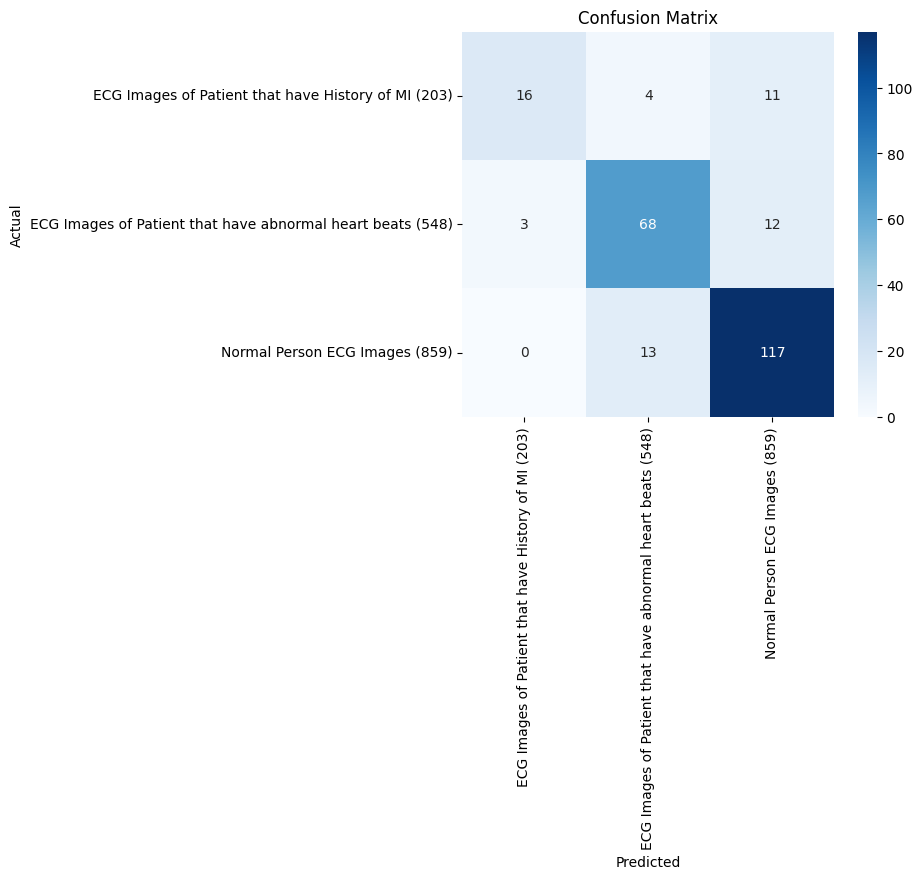

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

# ----------------------------
# ⚙️ Config
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
EPOCHS = 15
LR = 0.0003
# NUM_CLASSES = 3 # This will now be determined dynamically

train_dir = "/content/dataset2/train"
val_dir   = "/content/dataset2/val"
test_dir  = "/content/dataset2/test"

# ----------------------------
# 🔄 Transforms (IMPORTANT for DenseNet)
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Added: Ensure 3 channels for DenseNet
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Added: Ensure 3 channels for DenseNet
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ----------------------------
# 📂 Load Data
# ----------------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names) # Dynamically set NUM_CLASSES
print("Classes:", class_names)
print("Number of classes (NUM_CLASSES):", NUM_CLASSES)

# ----------------------------
# 🧠 Load DenseNet201
# ----------------------------
# Changed to explicitly use DenseNet201_Weights for robustness with older torchvision
model = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)

# Debug: Print in_features before replacing classifier
print(f"Original classifier in_features: {model.classifier.in_features}")

# Freeze backbone (optional but recommended initially)
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)

# Debug: Print new classifier details
print(f"New classifier: {model.classifier}")

model = model.to(device)

# ----------------------------
# ⚖️ Loss + Optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# 🔁 Training + Validation
# ----------------------------
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---- Training ----
    model.train()
    train_loss = 0.0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()

    train_acc = correct / len(train_dataset)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()

    val_acc = correct / len(val_dataset)

    print(f"Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# Load best model
model.load_state_dict(best_model_wts)

# ----------------------------
# 🧪 Test Evaluation
# ----------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ----------------------------
# 📊 Classification Report
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ----------------------------
# 📉 Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

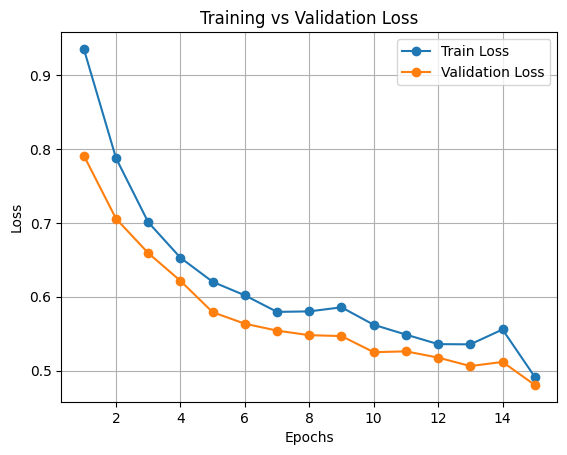

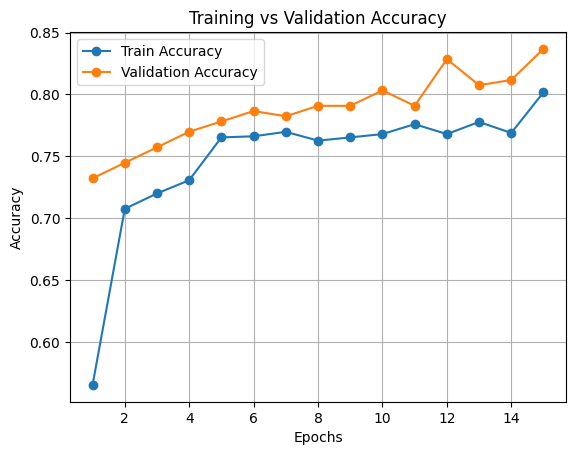

In [15]:
import matplotlib.pyplot as plt

# Data
train_loss = [0.9353, 0.7875, 0.7008, 0.6528, 0.6202,
              0.6019, 0.5795, 0.5802, 0.5857, 0.5621,
              0.5488, 0.5359, 0.5356, 0.5557, 0.4917]

val_loss = [0.7911, 0.7056, 0.6591, 0.6215, 0.5791,
            0.5635, 0.5542, 0.5480, 0.5468, 0.5250,
            0.5261, 0.5177, 0.5062, 0.5118, 0.4807]

train_acc = [0.5653, 0.7076, 0.7200, 0.7307, 0.7653,
             0.7662, 0.7698, 0.7627, 0.7653, 0.7680,
             0.7760, 0.7680, 0.7778, 0.7689, 0.8018]

val_acc = [0.7322, 0.7448, 0.7573, 0.7699, 0.7782,
           0.7866, 0.7824, 0.7908, 0.7908, 0.8033,
           0.7908, 0.8285, 0.8075, 0.8117, 0.8368]

epochs = range(1, 16)

# 🔹 Plot Loss
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

# 🔹 Plot Accuracy
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()